Block 1 — Import & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# LOCAL LOAD - baca CSV dari folder project (bukan Colab upload)
data_path = Path(r'E:\Work-Project\machine-learning-tr\ai4i2020.csv')
if not data_path.exists():
    data_path = Path('ai4i2020.csv')
if not data_path.exists():
    raise FileNotFoundError('ai4i2020.csv tidak ditemukan di folder project')

df = pd.read_csv(data_path)
print(f'File: {data_path.resolve()}')
print(df.shape)
df.head()

def detect_xgb_gpu():
    try:
        X = np.random.randn(64, 4)
        y = (X[:, 0] > 0).astype(int)
        XGBClassifier(n_estimators=1, device='cuda', tree_method='hist').fit(X, y)
        return {'device': 'cuda', 'tree_method': 'hist'}
    except Exception as e:
        print(f'XGBoost GPU tidak tersedia, pakai CPU. ({type(e).__name__})')
        return {'device': 'cpu', 'tree_method': 'hist'}

def detect_catboost_gpu():
    try:
        from catboost import CatBoostClassifier
        X = np.random.randn(64, 4)
        y = (X[:, 0] > 0).astype(int)
        CatBoostClassifier(iterations=1, task_type='GPU', verbose=0).fit(X, y)
        return {'task_type': 'GPU'}
    except Exception as e:
        print(f'CatBoost GPU tidak tersedia, pakai CPU. ({type(e).__name__})')
        return {'task_type': 'CPU'}

XGB_DEVICE = detect_xgb_gpu()
CB_DEVICE = detect_catboost_gpu()
GPU_N_JOBS = 1 if XGB_DEVICE.get('device') == 'cuda' else -1

print(f'XGBoost device: {XGB_DEVICE}')
print(f'CatBoost device: {CB_DEVICE}')
print(f'Search n_jobs (GPU-safe): {GPU_N_JOBS}')


Block 2 — EDA: Distribusi Target & Failure Modes

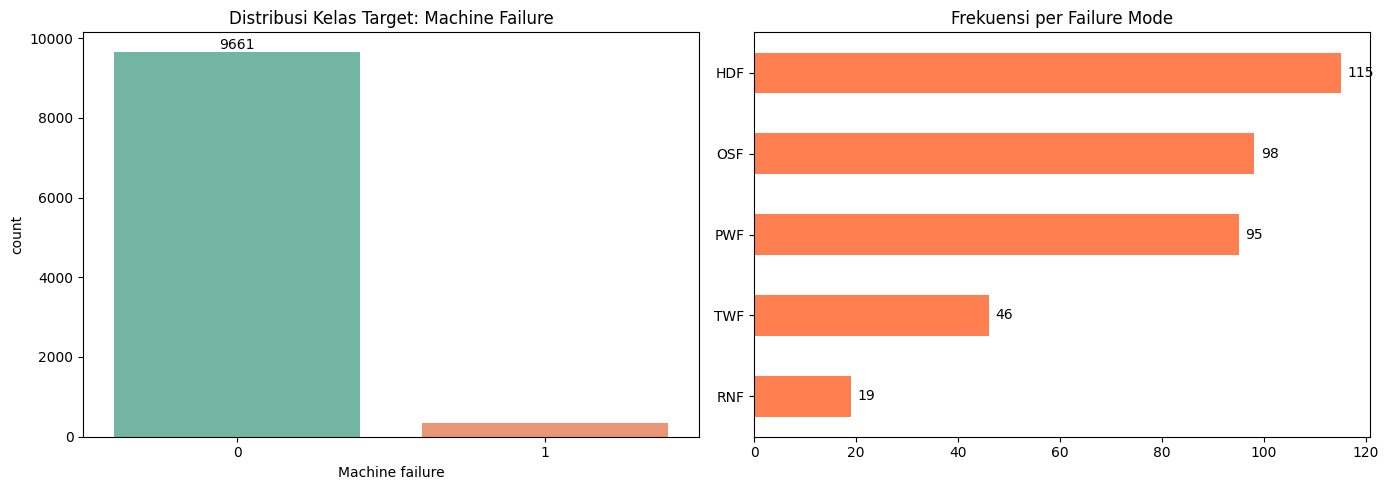

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Machine failure distribution
sns.countplot(x='Machine failure', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Distribusi Kelas Target: Machine Failure')
axes[0].bar_label(axes[0].containers[0])

# Plot 2: Failure mode frequencies
failure_modes = df[['TWF','HDF','PWF','OSF','RNF']].sum()
failure_modes.sort_values().plot(kind='barh', color='coral', ax=axes[1])
axes[1].set_title('Frekuensi per Failure Mode')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=5)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150)
plt.show()

Block 3 — EDA: Distribusi Fitur Sensor (Histogram + KDE)

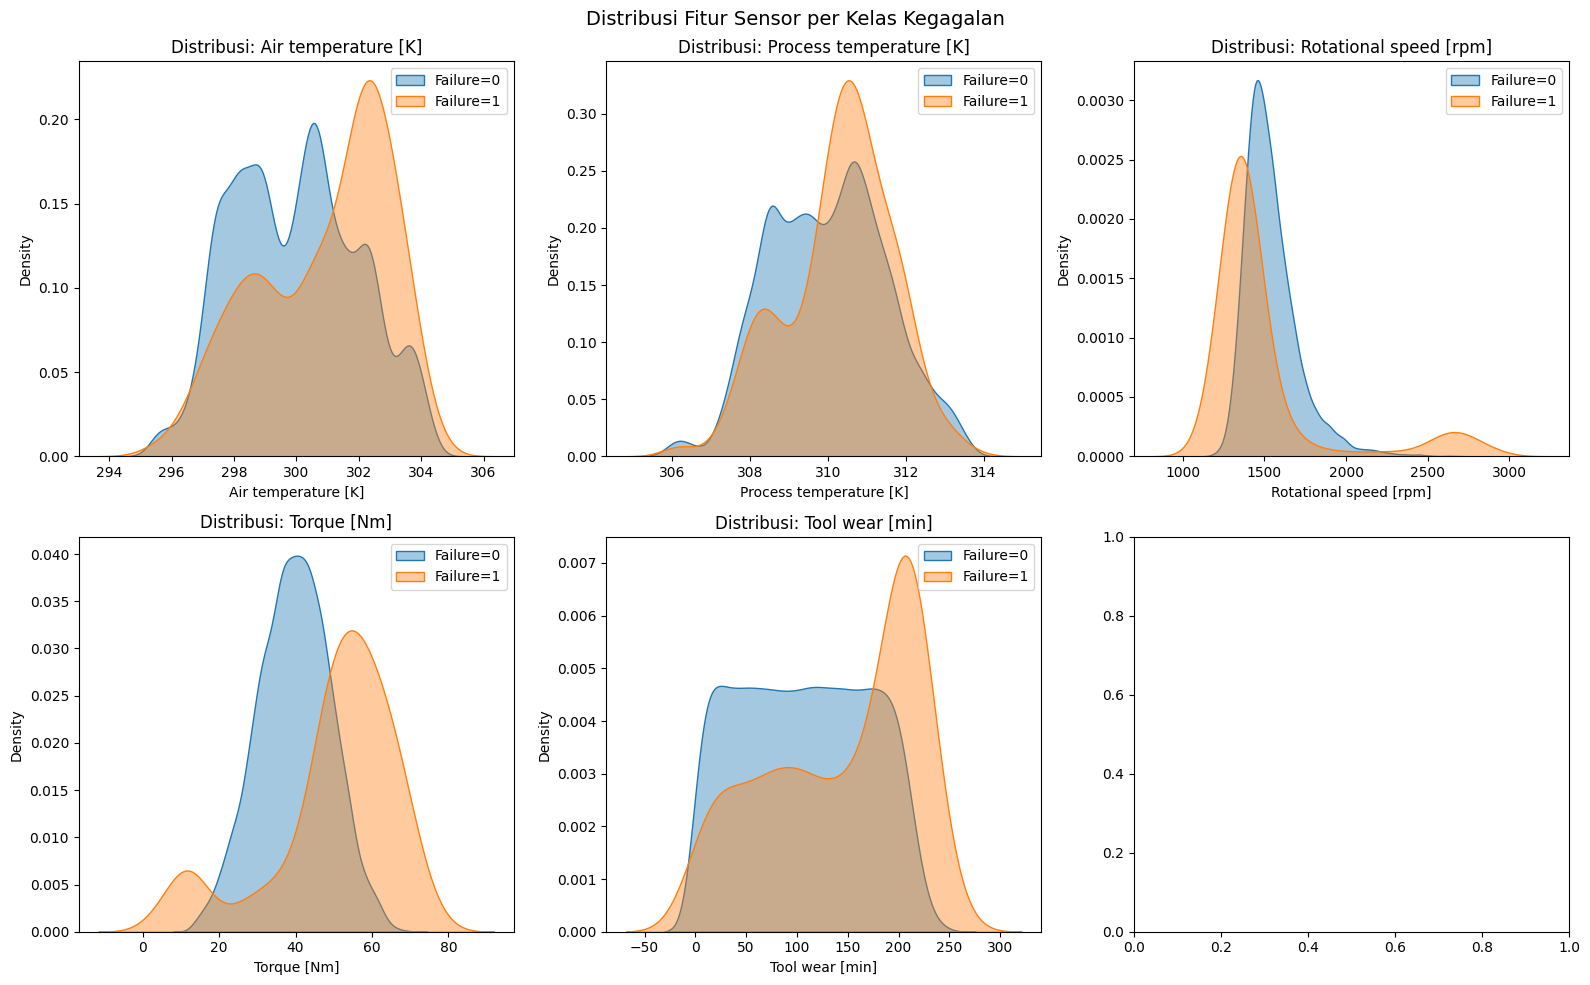

In [ ]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for label, grp in df.groupby('Machine failure'):
        sns.kdeplot(grp[col], ax=axes[i], label=f'Failure={label}', fill=True, alpha=0.4)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].legend()
plt.suptitle('Distribusi Fitur Sensor per Kelas Kegagalan', fontsize=14)
plt.tight_layout()
plt.savefig('fig2_sensor_distribution.png', dpi=150)
plt.show()

Block 4 — EDA: Boxplot Sensor vs Machine Failure

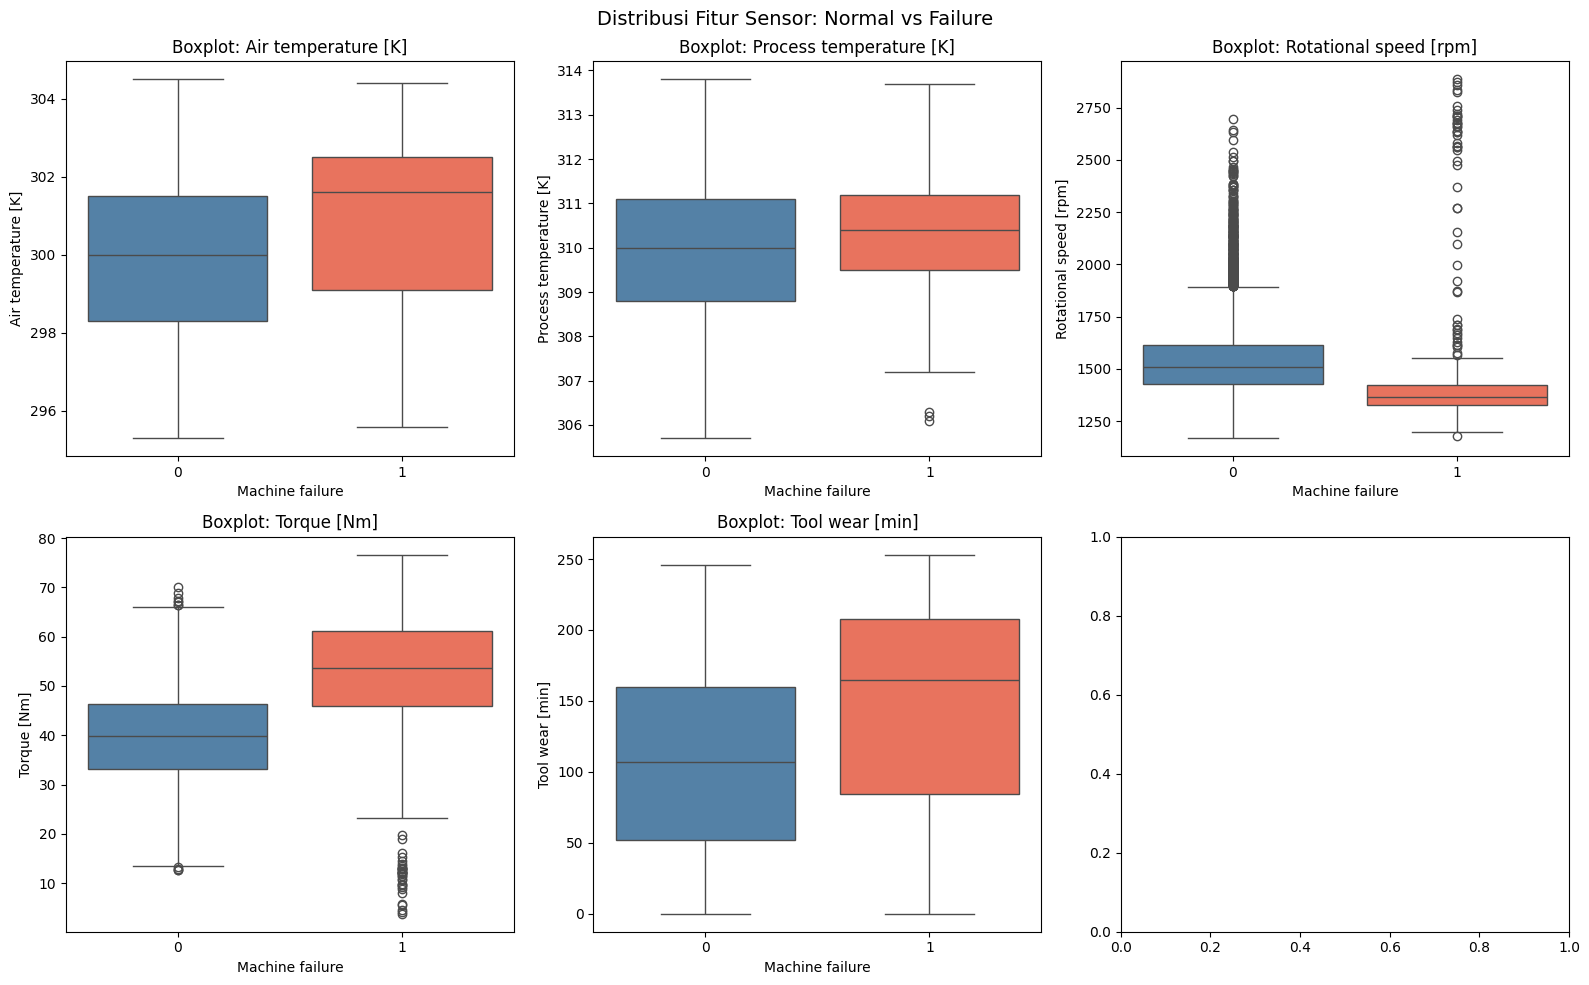

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x='Machine failure', y=col, data=df,
                palette={'0':'steelblue', '1':'tomato'}, ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.suptitle('Distribusi Fitur Sensor: Normal vs Failure', fontsize=14)
plt.tight_layout()
plt.savefig('fig3_boxplot_sensor.png', dpi=150)
plt.show()

Block 5 — EDA: Heatmap Korelasi

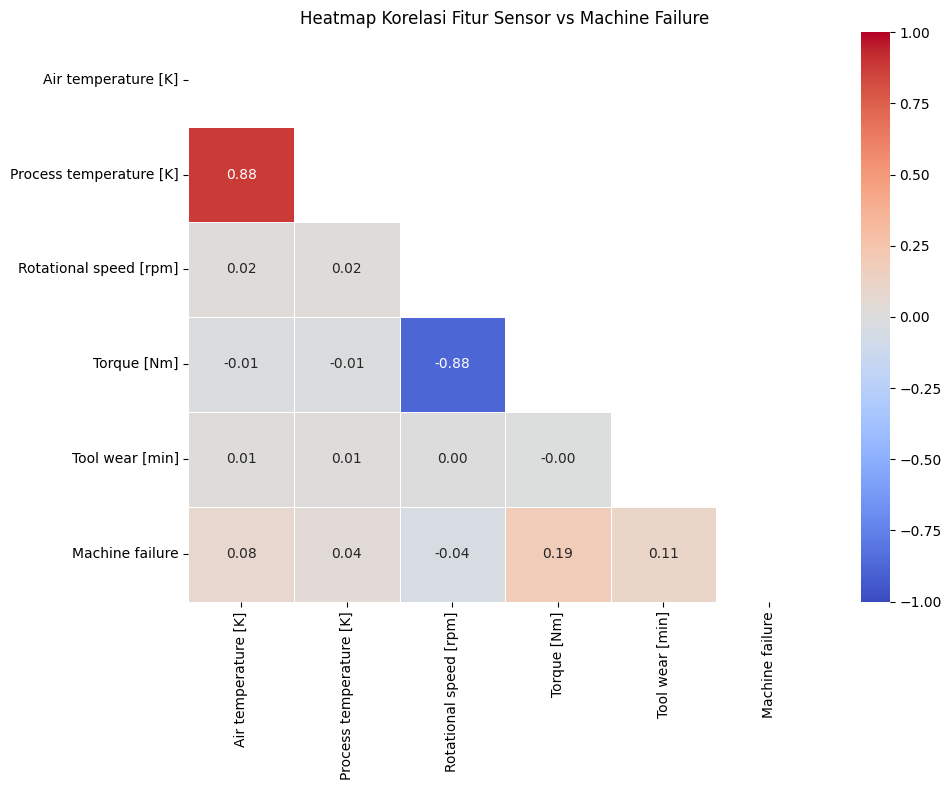

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['Machine failure']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Sensor vs Machine Failure')
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150)
plt.show()

Block 6 — EDA: Scatter Plot Zona Kegagalan

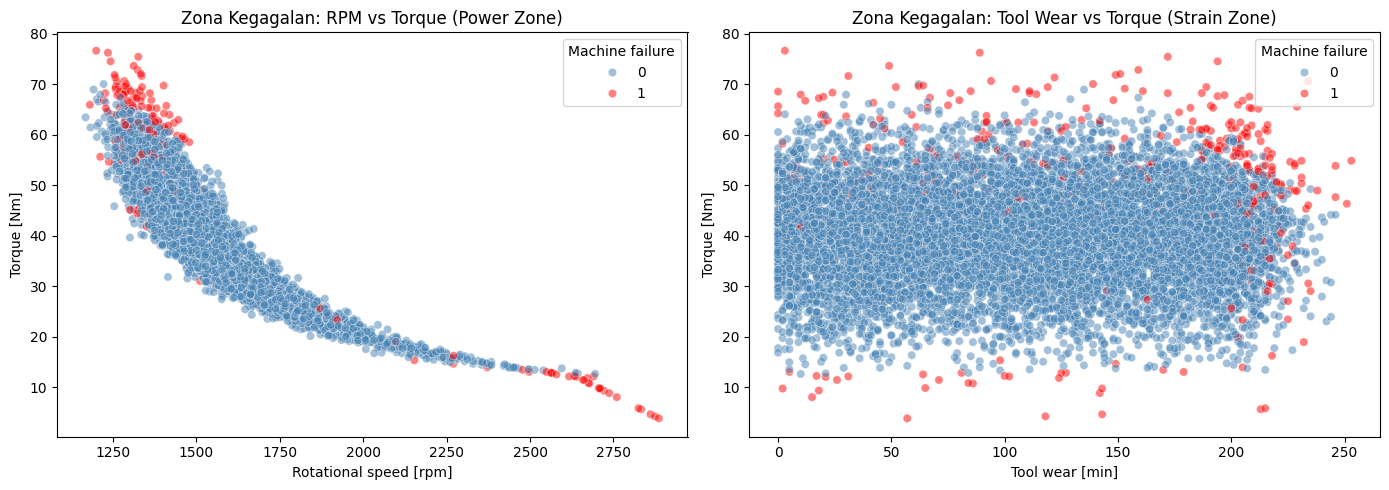

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter 1: RPM vs Torque
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]',
                hue='Machine failure', palette={0:'steelblue', 1:'red'},
                alpha=0.5, data=df, ax=axes[0])
axes[0].set_title('Zona Kegagalan: RPM vs Torque (Power Zone)')

# Scatter 2: Tool Wear vs Torque
sns.scatterplot(x='Tool wear [min]', y='Torque [Nm]',
                hue='Machine failure', palette={0:'steelblue', 1:'red'},
                alpha=0.5, data=df, ax=axes[1])
axes[1].set_title('Zona Kegagalan: Tool Wear vs Torque (Strain Zone)')
plt.tight_layout()
plt.savefig('fig5_scatter_failure_zones.png', dpi=150)
plt.show()

Block 7 — Preprocessing: Feature Engineering + Encoding

In [ ]:
# Feature engineering
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power']     = df['Rotational speed [rpm]'] * df['Torque [Nm]']
df['Strain']    = df['Torque [Nm]'] * df['Tool wear [min]']

# Encoding tipe produk
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})

# Hapus kolom tidak informatif
df.drop(['UDI', 'Product ID'], axis=1, inplace=True, errors='ignore')

print("Shape setelah preprocessing:", df.shape)
print(df.dtypes)

Shape setelah preprocessing: (10000, 15)
Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Temp_diff                  float64
Power                      float64
Strain                     float64
dtype: object


Block 8 — Preprocessing: Deteksi & Winsorization Outlier

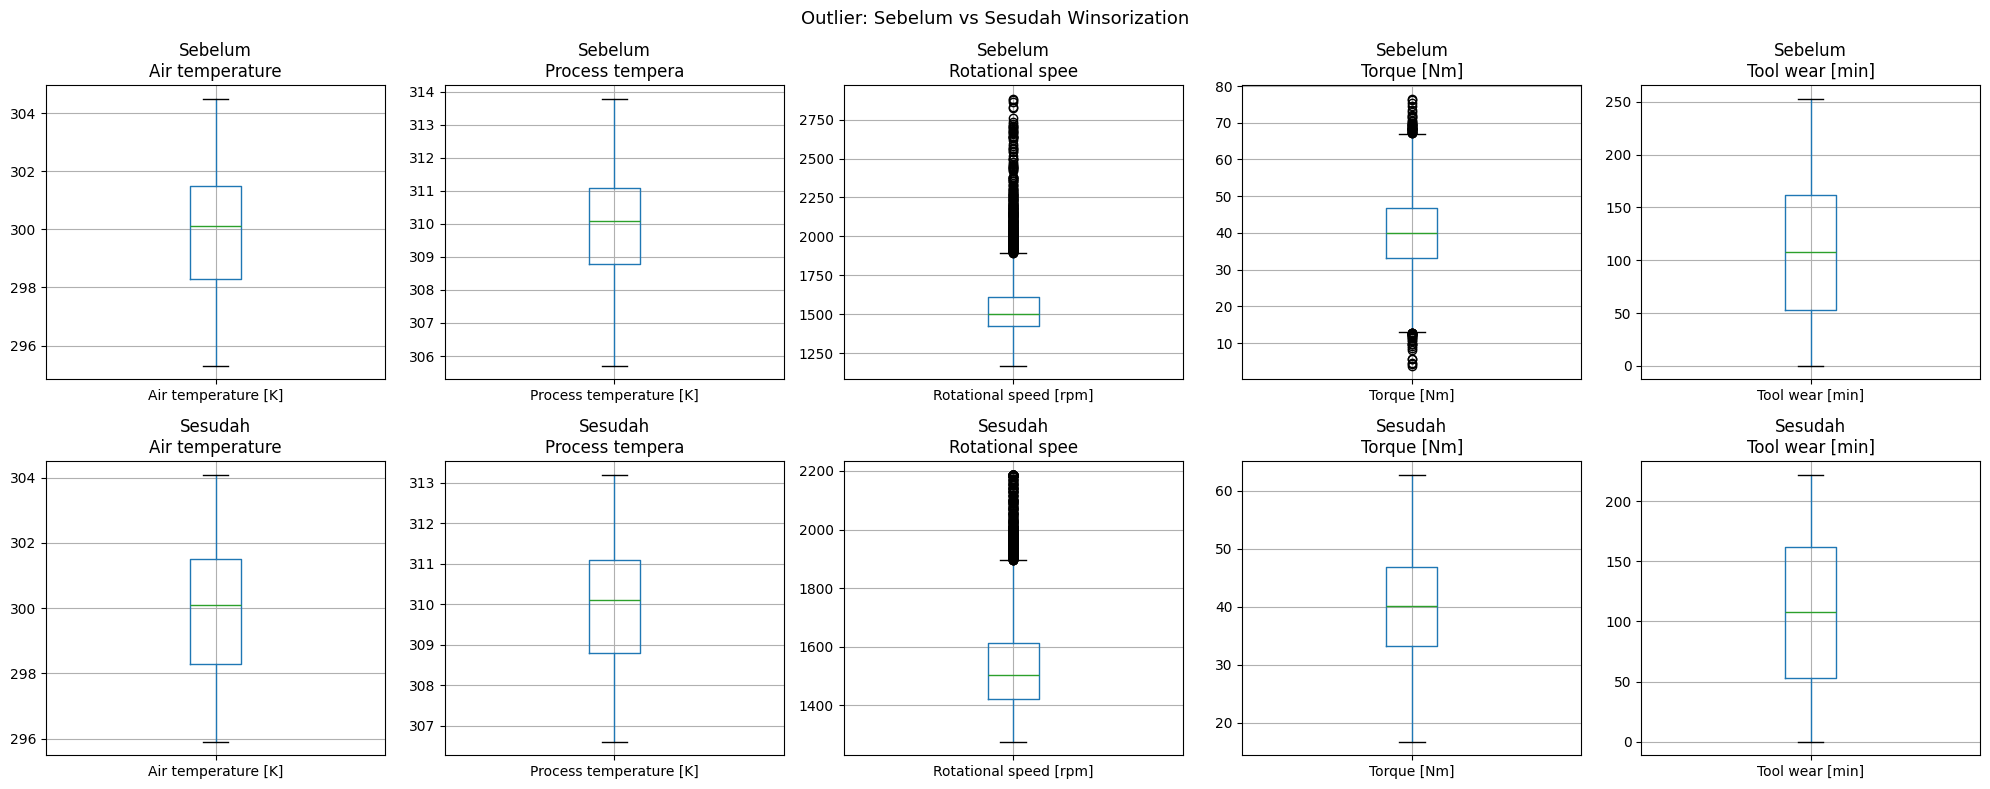

In [ ]:
from scipy.stats.mstats import winsorize

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
all_num = ['Air temperature [K]', 'Process temperature [K]',
           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for i, col in enumerate(all_num):
    # Sebelum
    df[[col]].boxplot(ax=axes[0, i])
    axes[0, i].set_title(f'Sebelum\n{col[:15]}')
    # Winsorize
    df[col] = winsorize(df[col], limits=[0.01, 0.01])
    # Sesudah
    df[[col]].boxplot(ax=axes[1, i])
    axes[1, i].set_title(f'Sesudah\n{col[:15]}')

plt.suptitle('Outlier: Sebelum vs Sesudah Winsorization', fontsize=13)
plt.tight_layout()
plt.savefig('fig6_outlier_treatment.png', dpi=150)
plt.show()

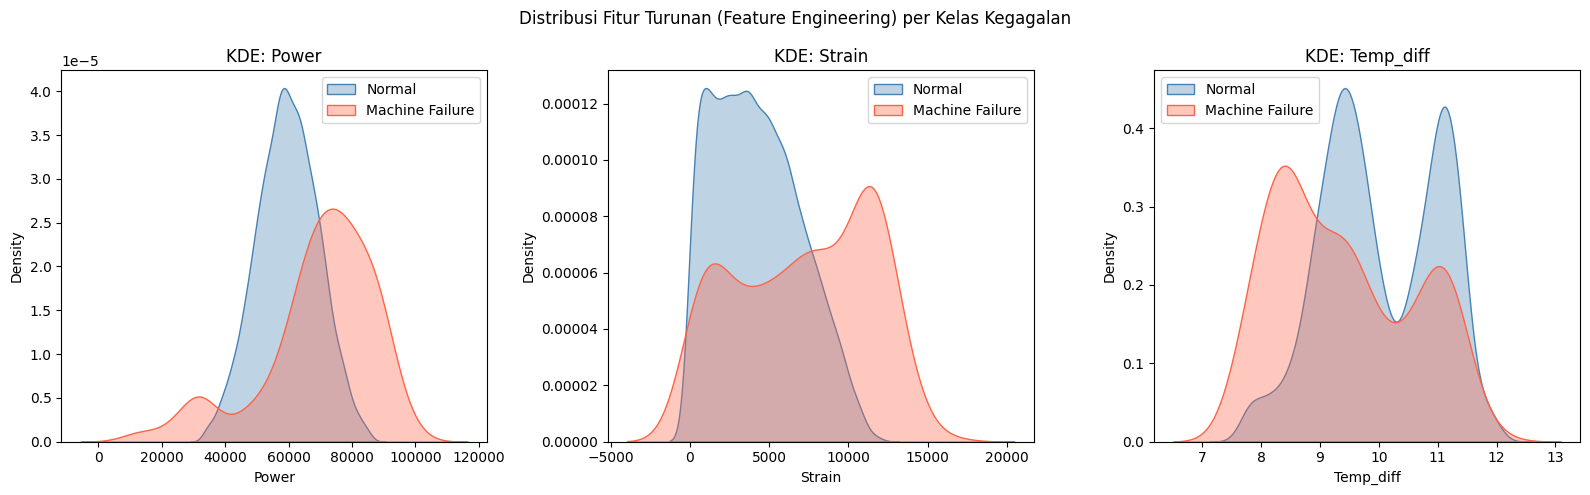

In [ ]:
# KDE Fitur Turunan (Feature Engineering)
derived_cols = ['Power', 'Strain', 'Temp_diff']
labels = {0: 'Normal', 1: 'Machine Failure'}
colors = {0: 'steelblue', 1: 'tomato'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(derived_cols):
    for label in [0, 1]:
        subset = df[df['Machine failure'] == label][col]
        sns.kdeplot(subset, ax=axes[i], label=labels[label],
                    color=colors[label], fill=True, alpha=0.35)
    axes[i].set_title(f'KDE: {col}')
    axes[i].legend()
plt.suptitle('Distribusi Fitur Turunan (Feature Engineering) per Kelas Kegagalan')
plt.tight_layout()
plt.savefig('fig8_kde_derived_features.png', dpi=150)
plt.show()


Block 9 — Preprocessing: Splitting + SMOTE

Train: (7000, 9), Val: (1000, 9), Test: (2000, 9)
Distribusi kelas Train sebelum SMOTE:
Machine failure
0    6763
1     237
Name: count, dtype: int64

Distribusi kelas Train sesudah SMOTE:
Machine failure
0    6763
1    2028
Name: count, dtype: int64


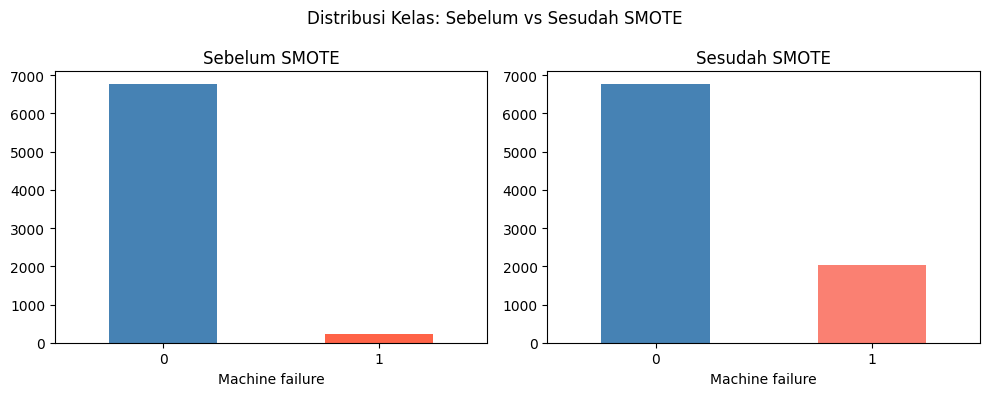

In [ ]:
X = df.drop(['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
y = df['Machine failure']

# Split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Distribusi kelas Train sebelum SMOTE:\n{y_train.value_counts()}")

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.3)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f"\nDistribusi kelas Train sesudah SMOTE:\n{pd.Series(y_res).value_counts()}")

# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'],
                             title='Sebelum SMOTE', rot=0)
pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','salmon'],
                                      title='Sesudah SMOTE', rot=0)
plt.suptitle('Distribusi Kelas: Sebelum vs Sesudah SMOTE')
plt.tight_layout()
plt.savefig('fig7_smote_comparison.png', dpi=150)
plt.show()

Block 10 — Inisialisasi Model (Rencana Assignment II)

In [ ]:
from sklearn.pipeline import Pipeline

# Standardisasi untuk Logistic Regression baseline dan model lain yang memerlukan data diskala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Model 1: XGBoost — GPU jika XGB_DEVICE = cuda
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    **XGB_DEVICE,
)

# Model 2: Random Forest (CPU)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Baseline: Logistic Regression (CPU)
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

print('Semua model siap digunakan pada Assignment II')
print(f'  XGBoost scale_pos_weight: {ratio:.2f}')
print(f'  XGBoost device: {XGB_DEVICE}')


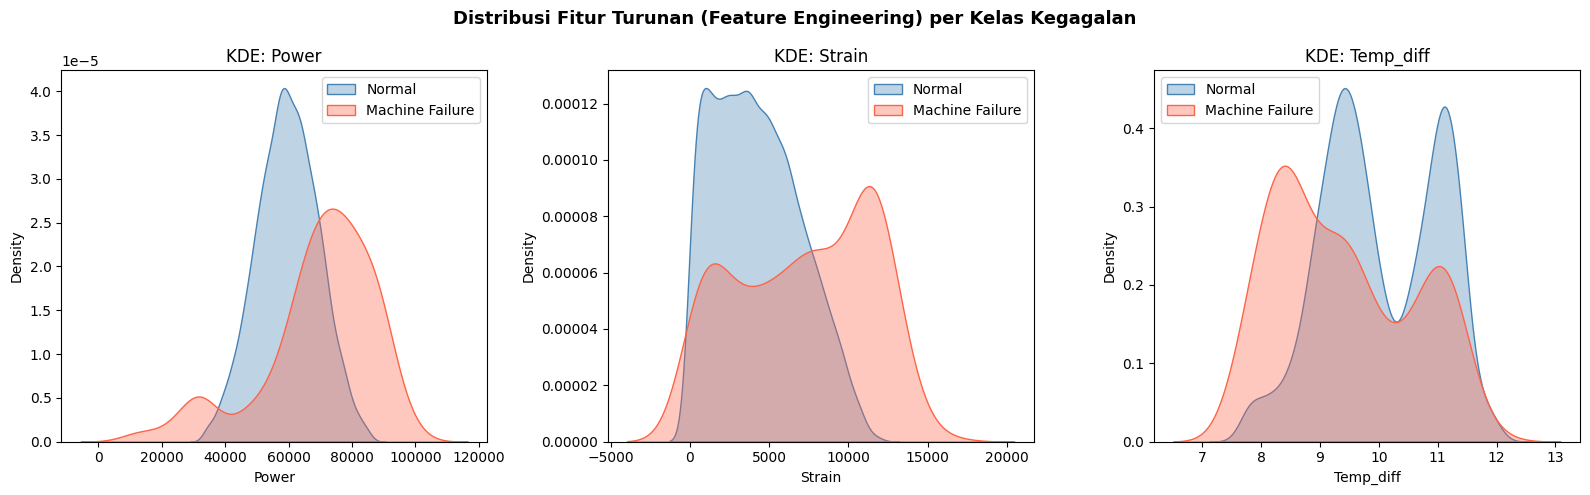

In [ ]:
derived_cols = ['Power', 'Strain', 'Temp_diff']
labels = {0: 'Normal', 1: 'Machine Failure'}
colors = {0: 'steelblue', 1: 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(derived_cols):
    for label in [0, 1]:
        subset = df[df['Machine failure'] == label][col]
        sns.kdeplot(subset, ax=axes[i],
                    label=labels[label],
                    color=colors[label],
                    fill=True, alpha=0.35)
    axes[i].set_title(f'KDE: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Distribusi Fitur Turunan (Feature Engineering) per Kelas Kegagalan',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_kde_derived_features.png', dpi=150)
plt.show()

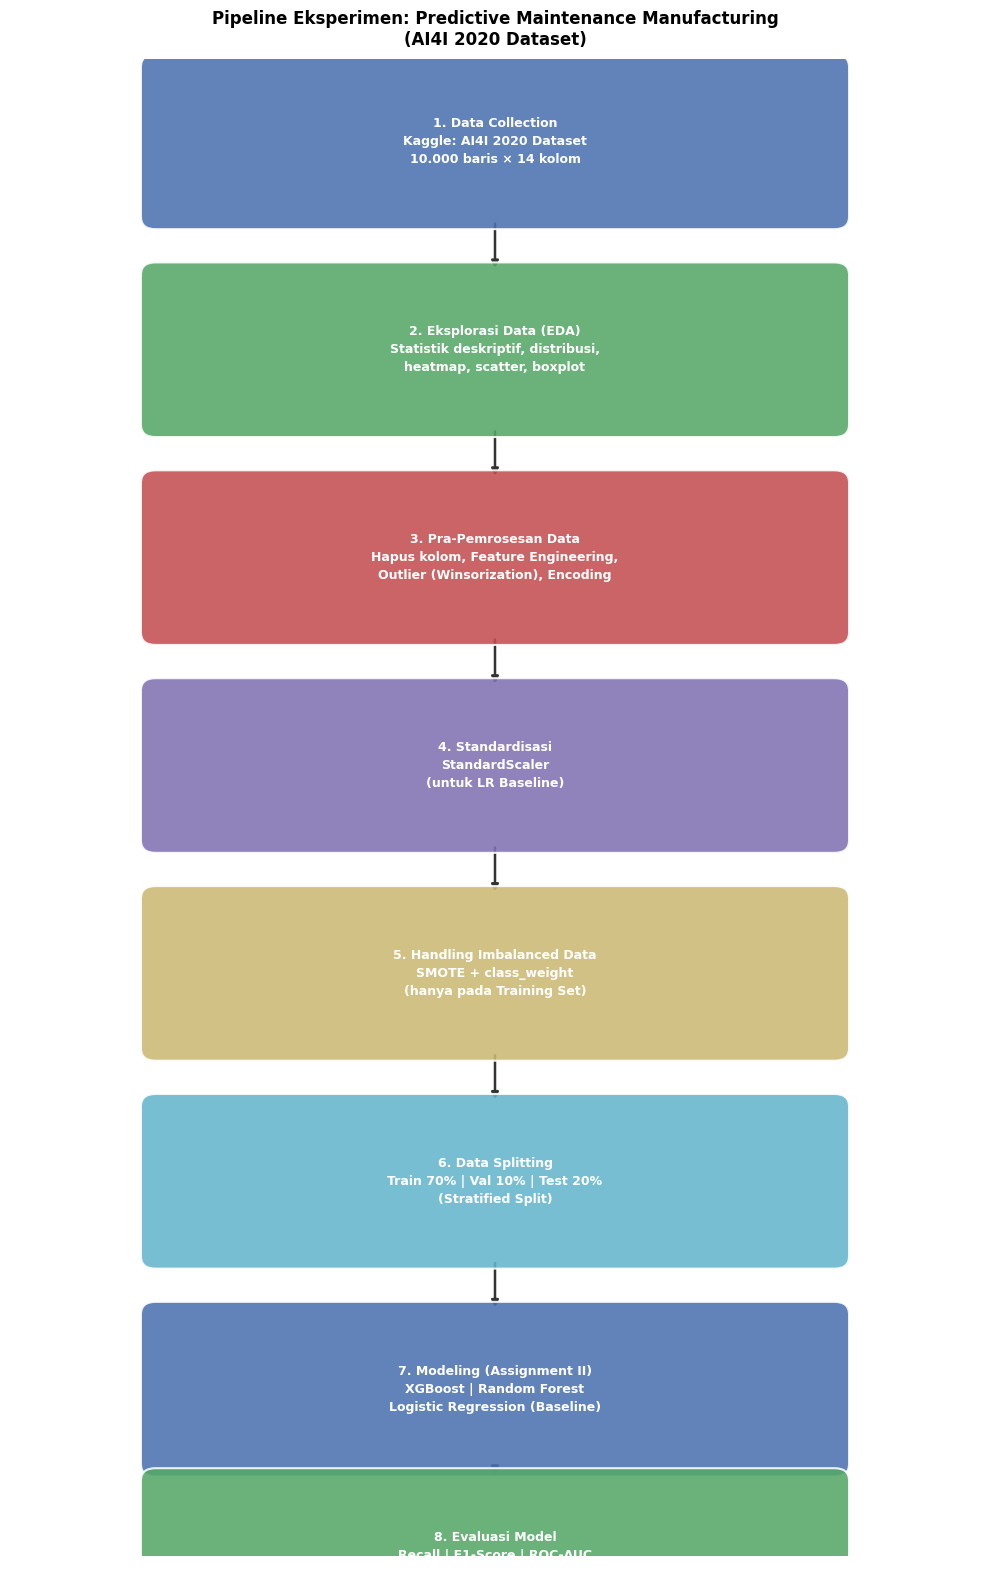

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(10, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')

# Definisi kotak: (x_center, y_center, label, warna)
steps = [
    (5, 17,   "1. Data Collection\nKaggle: AI4I 2020 Dataset\n10.000 baris × 14 kolom",  "#4C72B0"),
    (5, 14.5, "2. Eksplorasi Data (EDA)\nStatistik deskriptif, distribusi,\nheatmap, scatter, boxplot",  "#55A868"),
    (5, 12,   "3. Pra-Pemrosesan Data\nHapus kolom, Feature Engineering,\nOutlier (Winsorization), Encoding", "#C44E52"),
    (5, 9.5,  "4. Standardisasi\nStandardScaler\n(untuk LR Baseline)",                   "#8172B2"),
    (5, 7,    "5. Handling Imbalanced Data\nSMOTE + class_weight\n(hanya pada Training Set)",            "#CCB974"),
    (5, 4.5,  "6. Data Splitting\nTrain 70% | Val 10% | Test 20%\n(Stratified Split)",   "#64B5CD"),
    (5, 2,    "7. Modeling (Assignment II)\nXGBoost | Random Forest\nLogistic Regression (Baseline)",    "#4C72B0"),
    (5, 0,    "8. Evaluasi Model\nRecall | F1-Score | ROC-AUC\nConfusion Matrix",         "#55A868"),
]

box_w, box_h = 7, 1.8

for (x, y, label, color) in steps:
    fancy = FancyBboxPatch((x - box_w/2, y - box_h/2),
                           box_w, box_h,
                           boxstyle="round,pad=0.15",
                           linewidth=1.5,
                           edgecolor='white',
                           facecolor=color,
                           alpha=0.88,
                           zorder=2)
    ax.add_patch(fancy)
    ax.text(x, y, label,
            ha='center', va='center',
            fontsize=9, color='white',
            fontweight='bold', zorder=3,
            linespacing=1.5)

# Gambar panah antar kotak
y_positions = [s[1] for s in steps]
for i in range(len(y_positions) - 1):
    y_start = y_positions[i] - box_h / 2
    y_end   = y_positions[i+1] + box_h / 2
    ax.annotate("",
                xy=(5, y_end + 0.05),
                xytext=(5, y_start - 0.05),
                arrowprops=dict(arrowstyle="-|>",
                                color='#333333',
                                lw=1.8),
                zorder=1)

plt.title('Pipeline Eksperimen: Predictive Maintenance Manufacturing\n(AI4I 2020 Dataset)',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('fig10_pipeline_flowchart.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Block 11 — Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Clean column names for XGBoost compatibility
X_res.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_res.columns]
X_val.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_val.columns]
X_test.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_test.columns]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tuning XGBoost (GPU)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 6],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    param_grid=xgb_params, scoring='f1', cv=cv, n_jobs=GPU_N_JOBS, verbose=1)
xgb_grid.fit(X_res, y_res)
print('Best XGBoost params:', xgb_grid.best_params_)
print('Best CV F1-Score:', xgb_grid.best_score_)

# Tuning Random Forest (CPU)
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
rf_grid.fit(X_res, y_res)
print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV F1-Score:', rf_grid.best_score_)

# Tuning Logistic Regression (Baseline, CPU)
lr_params = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']}
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000),
    param_grid=lr_params, scoring='f1', cv=cv, n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
print('Best LR params:', lr_grid.best_params_)


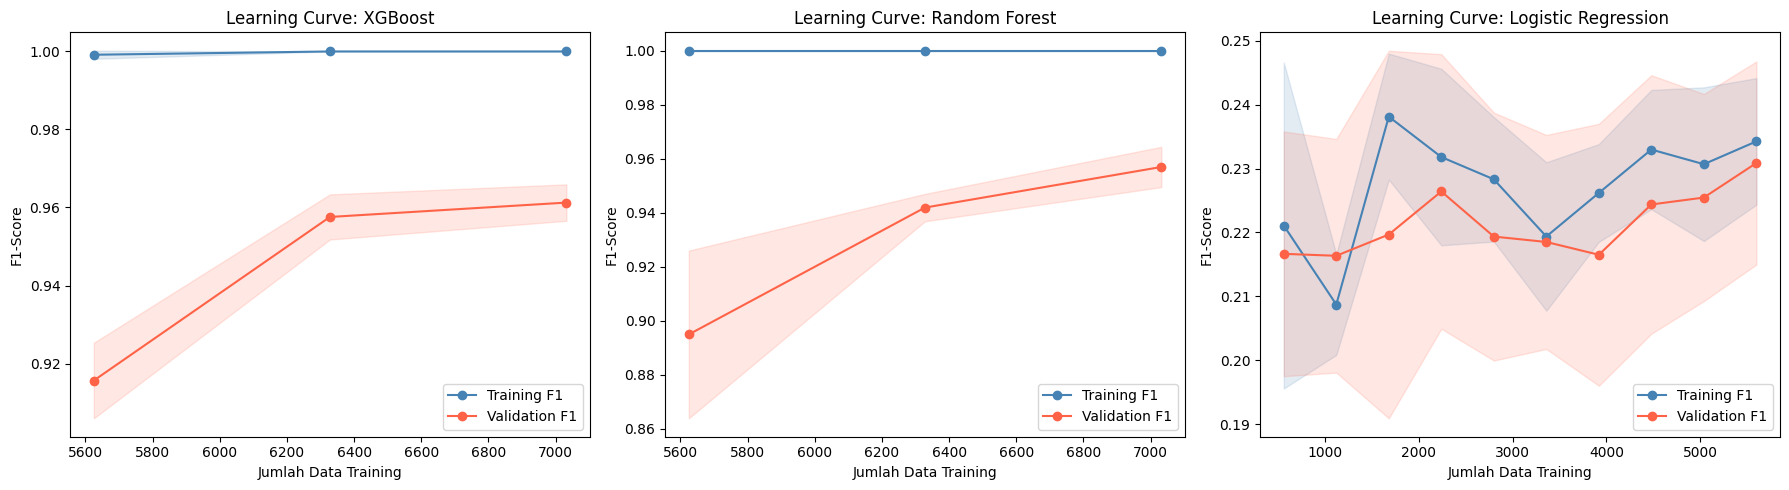

XGBoost — Train F1: 0.9998 | Val F1: 0.7229
Random Forest — Train F1: 1.0000 | Val F1: 0.8955
Logistic Regression — Train F1: 0.2356 | Val F1: 0.2333


In [ ]:
# Block 12 — Observasi Overfitting/Underfitting via Learning Curve
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
    plt.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validation F1')
    plt.fill_between(train_sizes, train_mean - train_scores.std(axis=1),
                      train_mean + train_scores.std(axis=1), alpha=0.15, color='steelblue')
    plt.fill_between(train_sizes, val_mean - val_scores.std(axis=1),
                      val_mean + val_scores.std(axis=1), alpha=0.15, color='tomato')
    plt.title(title)
    plt.xlabel('Jumlah Data Training')
    plt.ylabel('F1-Score')
    plt.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.sca(axes[0]); plot_learning_curve(xgb_grid.best_estimator_, X_res, y_res, 'Learning Curve: XGBoost')
plt.sca(axes[1]); plot_learning_curve(rf_grid.best_estimator_, X_res, y_res, 'Learning Curve: Random Forest')
plt.sca(axes[2]); plot_learning_curve(lr_grid.best_estimator_, X_train_scaled, y_train, 'Learning Curve: Logistic Regression')
plt.tight_layout()
plt.savefig('fig11_learning_curves.png', dpi=150)
plt.show()

# Perbandingan skor training vs validation langsung
for name, model, X_tr, y_tr in [
    ('XGBoost', xgb_grid.best_estimator_, X_res, y_res),
    ('Random Forest', rf_grid.best_estimator_, X_res, y_res),
    ('Logistic Regression', lr_grid.best_estimator_, X_train_scaled, y_train)
]:
    train_pred = model.predict(X_tr)
    val_pred = model.predict(X_val_scaled if name == 'Logistic Regression' else X_val)
    print(f"{name} — Train F1: {f1_score(y_tr, train_pred):.4f} | Val F1: {f1_score(y_val, val_pred):.4f}")

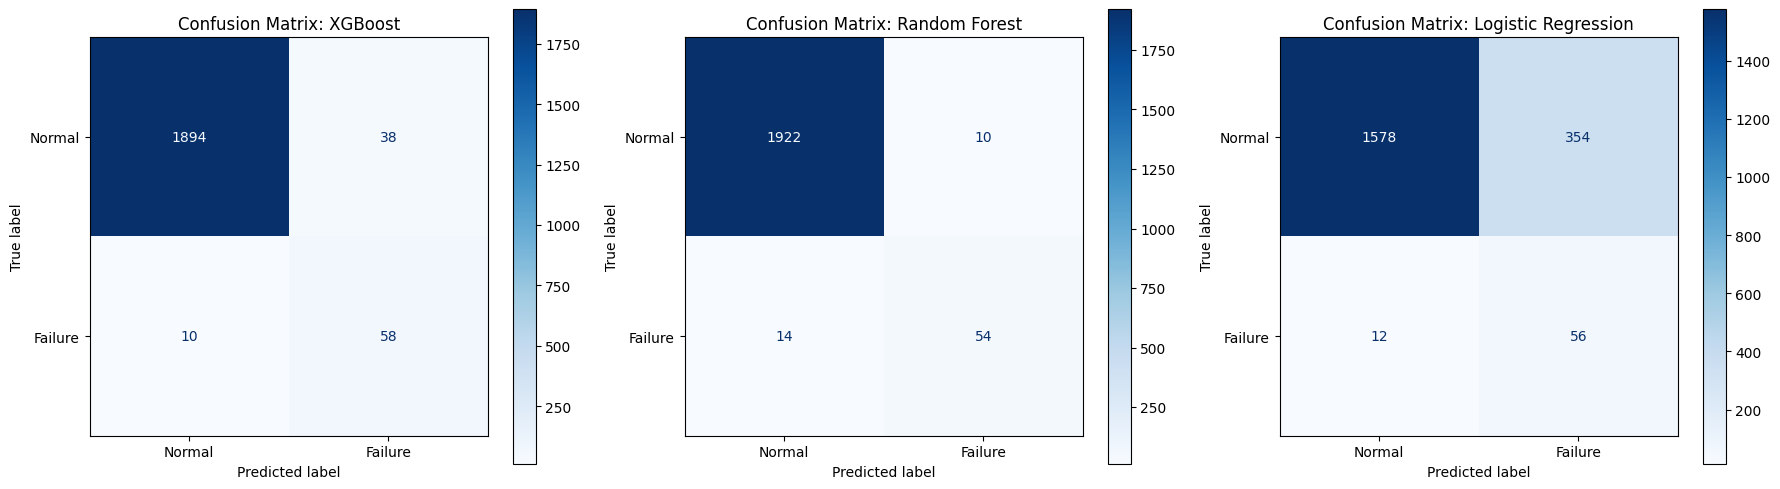

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0              XGBoost     0.976   0.604167  0.852941  0.707317  0.982364
1        Random Forest     0.988   0.843750  0.794118  0.818182  0.984746
2  Logistic Regression     0.817   0.136585  0.823529  0.234310  0.905896


In [ ]:
# Block 13 — Evaluasi Model pada Test Set
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

models_final = {
    'XGBoost': xgb_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'Logistic Regression': lr_grid.best_estimator_
}

results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models_final.items()):
    X_eval = X_test_scaled if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Failure']).plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.savefig('fig12_confusion_matrices.png', dpi=150)
plt.show()

results_df = pd.DataFrame(results)
print(results_df)

In [ ]:
# Block 14 — Evaluasi via K-Fold Cross Validation
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
scoring = ['f1', 'recall', 'precision', 'roc_auc']

cv_summary = []
for name, model in models_final.items():
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_res
    y_cv = y_train if name == 'Logistic Regression' else y_res
    cv_results = cross_validate(model, X_cv, y_cv, cv=rskf, scoring=scoring, n_jobs=-1)
    cv_summary.append({
        'Model': name,
        'CV F1 (mean±std)': f"{cv_results['test_f1'].mean():.3f} ± {cv_results['test_f1'].std():.3f}",
        'CV Recall (mean±std)': f"{cv_results['test_recall'].mean():.3f} ± {cv_results['test_recall'].std():.3f}",
        'CV ROC-AUC (mean±std)': f"{cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}"
    })
pd.DataFrame(cv_summary)

,Model,CV F1 (mean±std),CV Recall (mean±std),CV ROC-AUC (mean±std)
0,XGBoost,0.964 ± 0.005,0.981 ± 0.007,0.999 ± 0.000
1,Random Forest,0.963 ± 0.005,0.950 ± 0.012,0.998 ± 0.001
2,Logistic Regression,0.233 ± 0.013,0.818 ± 0.050,0.887 ± 0.020


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00


In [ ]:
# Block 15 — Eksperimen Algoritma Tambahan
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

extended_models = {
    'LightGBM': LGBMClassifier(scale_pos_weight=ratio, random_state=42, verbose=-1),  # CPU
    'CatBoost': CatBoostClassifier(scale_pos_weight=ratio, random_state=42, verbose=0, **CB_DEVICE),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'ANN (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

extended_results = []
for name, model in extended_models.items():
    X_tr = X_train_scaled if name in ['SVM', 'KNN', 'Naive Bayes', 'ANN (MLP)'] else X_res
    y_tr = y_train if name in ['SVM', 'KNN', 'Naive Bayes', 'ANN (MLP)'] else y_res
    X_ev = X_test_scaled if name in ['SVM', 'KNN', 'Naive Bayes', 'ANN (MLP)'] else X_test

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    extended_results.append({
        'Model': name,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred)
    })

extended_df = pd.DataFrame(extended_results).sort_values('F1-Score', ascending=False)
print(extended_df)
print('CatBoost device:', CB_DEVICE)


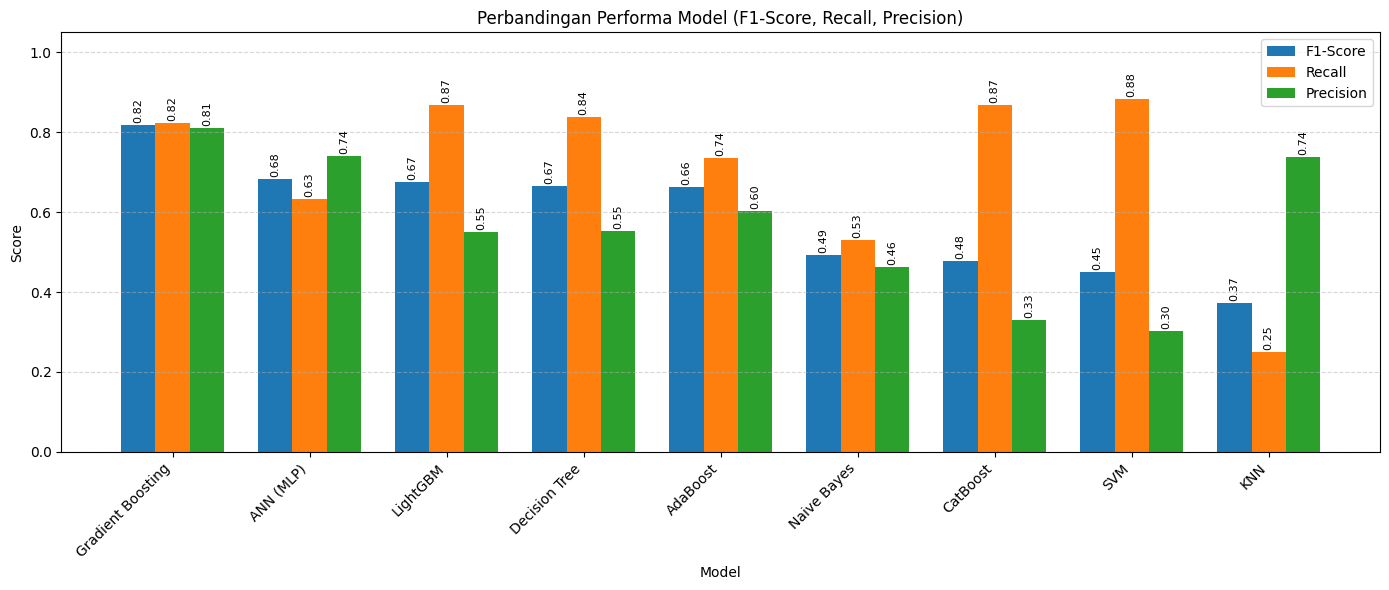

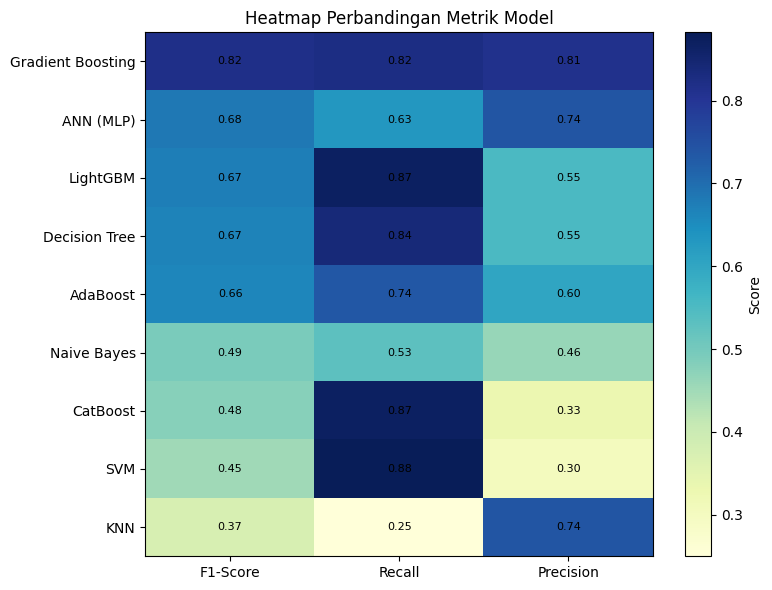

In [ ]:
# Block 16 — Visualisasi Perbandingan Model
import matplotlib.pyplot as plt
import numpy as np

metrics = ['F1-Score', 'Recall', 'Precision']
models = extended_df['Model'].tolist()
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, extended_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model (F1-Score, Recall, Precision)')
ax.set_xticks(x + width)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, metric in enumerate(metrics):
    for j, val in enumerate(extended_df[metric]):
        ax.text(j + i * width, val + 0.01, f'{val:.2f}', ha='center', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# (Opsional) Heatmap perbandingan
plt.figure(figsize=(8, 6))
heatmap_data = extended_df.set_index('Model')[metrics]
plt.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')
plt.colorbar(label='Score')
plt.xticks(range(len(metrics)), metrics)
plt.yticks(range(len(models)), models)
for i in range(len(models)):
    for j in range(len(metrics)):
        plt.text(j, i, f'{heatmap_data.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
plt.title('Heatmap Perbandingan Metrik Model')
plt.tight_layout()
plt.show()

Block 17 — Regularisasi XGBoost & Random Forest

In [ ]:
!pip install shap statsmodels imbalanced-learn catboost lightgbm -q

In [ ]:
# Block 17 — Perbaikan Overfitting: Re-Tuning dengan Regularisasi Ketat
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_params_v2 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 4],
    'subsample': [0.7, 0.8],
    'reg_alpha': [0.1, 1, 5],
    'reg_lambda': [1, 5, 10],
    'colsample_bytree': [0.7, 0.9]
}
xgb_grid_v2 = GridSearchCV(
    XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    param_grid=xgb_params_v2, scoring='f1', cv=cv, n_jobs=GPU_N_JOBS, verbose=1)
xgb_grid_v2.fit(X_res, y_res)
print('XGBoost v2 (Regularized) — Best params:', xgb_grid_v2.best_params_)
print('XGBoost v2 — Best CV F1-Score:', xgb_grid_v2.best_score_)

rf_params_v2 = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [5, 8, 10],
    'class_weight': ['balanced', 'balanced_subsample']
}
rf_grid_v2 = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params_v2, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
rf_grid_v2.fit(X_res, y_res)
print('Random Forest v2 (Regularized) — Best params:', rf_grid_v2.best_params_)
print('Random Forest v2 — Best CV F1-Score:', rf_grid_v2.best_score_)

from sklearn.metrics import f1_score
for name, model in [('XGBoost v2', xgb_grid_v2.best_estimator_), ('Random Forest v2', rf_grid_v2.best_estimator_)]:
    train_pred = model.predict(X_res)
    val_pred = model.predict(X_val)
    train_f1 = f1_score(y_res, train_pred)
    val_f1 = f1_score(y_val, val_pred)
    gap = train_f1 - val_f1
    print(f'{name} — Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {gap:.4f}')


Block 18 — Sensitivitas Rasio SMOTE

In [ ]:
# Block 18 — Eksperimen Sensitivitas Rasio SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.metrics import recall_score, precision_score

smote_ratios = [0.2, 0.5, 0.7, 1.0]
smote_results = []

for ratio_smote in smote_ratios:
    smote = SMOTE(sampling_strategy=ratio_smote, random_state=42)
    X_res_r, y_res_r = smote.fit_resample(X_train, y_train)
    X_res_r.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_res_r.columns]

    model = XGBClassifier(
        **{k: v for k, v in xgb_grid_v2.best_params_.items()},
        scale_pos_weight=1, eval_metric='logloss', random_state=42, **XGB_DEVICE
    )
    model.fit(X_res_r, y_res_r)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    smote_results.append({
        'SMOTE_Ratio': ratio_smote,
        'Val_F1': f1_score(y_val, val_pred),
        'Test_F1': f1_score(y_test, test_pred),
        'Test_Recall': recall_score(y_test, test_pred),
        'Test_Precision': precision_score(y_test, test_pred)
    })

smote_df = pd.DataFrame(smote_results)
print(smote_df)

smotetomek = SMOTETomek(random_state=42)
X_res_st, y_res_st = smotetomek.fit_resample(X_train, y_train)
X_res_st.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_res_st.columns]

model_st = XGBClassifier(**xgb_grid_v2.best_params_, scale_pos_weight=1, eval_metric='logloss', random_state=42, **XGB_DEVICE)
model_st.fit(X_res_st, y_res_st)
test_pred_st = model_st.predict(X_test)
print(f'\nSMOTETomek — Test F1: {f1_score(y_test, test_pred_st):.4f} | Recall: {recall_score(y_test, test_pred_st):.4f} | Precision: {precision_score(y_test, test_pred_st):.4f}')

smote_df.to_csv('smote_sensitivity_results.csv', index=False)


In [ ]:
# Block A — Perbaikan XGBoost: Regularisasi, Early Stopping, Scoring pada Val Set Asli
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import f1_score, make_scorer
import numpy as np

X_combined = np.vstack([X_res, X_val])
y_combined = np.concatenate([y_res, y_val])
test_fold = np.concatenate([
    np.full(len(X_res), -1),
    np.full(len(X_val), 0)
])
ps = PredefinedSplit(test_fold)

xgb_params_v2 = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [2, 3, 4],
    'subsample': [0.7, 0.8],
    'reg_alpha': [0, 0.5, 1, 5],
    'reg_lambda': [1, 5, 10]
}

xgb_grid_v2 = GridSearchCV(
    XGBClassifier(scale_pos_weight=ratio, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    param_grid=xgb_params_v2,
    scoring='f1',
    cv=ps,
    n_jobs=GPU_N_JOBS, verbose=1
)
xgb_grid_v2.fit(X_combined, y_combined)
print('Best XGBoost params (v2):', xgb_grid_v2.best_params_)
print('Best F1 on real validation set:', xgb_grid_v2.best_score_)

best_params = xgb_grid_v2.best_params_
xgb_final = XGBClassifier(
    **best_params,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=20,
    **XGB_DEVICE,
)
xgb_final.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=False)

train_f1 = f1_score(y_res, xgb_final.predict(X_res))
val_f1 = f1_score(y_val, xgb_final.predict(X_val))
print(f'XGBoost v2 — Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {train_f1-val_f1:.4f}')


In [ ]:
# Block A-v2 — Kombinasi: Scoring pada Val Asli + SMOTE Ratio 0.2
from imblearn.over_sampling import SMOTE

smote_02 = SMOTE(sampling_strategy=0.2, random_state=42)
X_res_02, y_res_02 = smote_02.fit_resample(X_train, y_train)
X_res_02.columns = [col.replace('[', '').replace(']', '').replace('<', '').replace(' ', '_') for col in X_res_02.columns]
ratio_02 = y_res_02.value_counts()[0] / y_res_02.value_counts()[1]

X_combined_02 = np.vstack([X_res_02, X_val])
y_combined_02 = np.concatenate([y_res_02, y_val])
test_fold_02 = np.concatenate([np.full(len(X_res_02), -1), np.full(len(X_val), 0)])
ps_02 = PredefinedSplit(test_fold_02)

xgb_grid_v4 = GridSearchCV(
    XGBClassifier(scale_pos_weight=ratio_02, eval_metric='logloss', random_state=42, **XGB_DEVICE),
    param_grid=xgb_params_v2, scoring='f1', cv=ps_02, n_jobs=GPU_N_JOBS, verbose=1
)
xgb_grid_v4.fit(X_combined_02, y_combined_02)

xgb_final_v4 = xgb_grid_v4.best_estimator_
train_f1_v4 = f1_score(y_res_02, xgb_final_v4.predict(X_res_02))
val_f1_v4 = f1_score(y_val, xgb_final_v4.predict(X_val))
test_pred_v4 = xgb_final_v4.predict(X_test)

print(f'XGBoost v4 (SMOTE 0.2 + val-scoring) — Train F1: {train_f1_v4:.4f} | Val F1: {val_f1_v4:.4f} | Gap: {train_f1_v4-val_f1_v4:.4f}')
print(f'Test F1: {f1_score(y_test, test_pred_v4):.4f} | Recall: {recall_score(y_test, test_pred_v4):.4f} | Precision: {precision_score(y_test, test_pred_v4):.4f}')


In [ ]:
# Block A-v3 — Grid Search pada validation asli TANPA refit ke gabungan train+validation
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

X_combined_02 = np.vstack([X_res_02, X_val])
y_combined_02 = np.concatenate([y_res_02, y_val])

test_fold_02 = np.concatenate([
    np.full(len(X_res_02), -1),
    np.zeros(len(X_val), dtype=int)
])

ps_02 = PredefinedSplit(test_fold_02)

xgb_params_v3 = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 5, 10]
}

xgb_grid_v3 = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=ratio_02,
        eval_metric='logloss',
        random_state=42,
        **XGB_DEVICE,
    ),
    param_grid=xgb_params_v3,
    scoring='f1',
    cv=ps_02,
    n_jobs=GPU_N_JOBS,
    verbose=1,
    refit=False
)

xgb_grid_v3.fit(X_combined_02, y_combined_02)

best_params_v3 = xgb_grid_v3.best_params_

print('Best parameters:', best_params_v3)
print(f'Best Validation F1: {xgb_grid_v3.best_score_:.4f}')


In [ ]:
# Block B — Perbaikan Random Forest: Batasi Depth, Naikkan min_samples_leaf/split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

rf_params_v2 = {
    'n_estimators': [100, 150, 200],
    'max_depth': [8, 12, 15, 20],           # dibatasi, tidak boleh None lagi
    'min_samples_split': [10, 20],          # dinaikkan dari [2,5,10]
    'min_samples_leaf': [3, 5, 10],         # parameter baru untuk cegah daun terlalu spesifik
    'max_features': ['sqrt'],               # tambah variasi antar pohon
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_grid_v2 = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params_v2,
    scoring='f1',
    cv=cv,                                   # tetap pakai StratifiedKFold 5-fold pada X_res
    n_jobs=-1, verbose=1
)
rf_grid_v2.fit(X_res, y_res)
print("Best Random Forest params (v2):", rf_grid_v2.best_params_)
print("Best CV F1-Score:", rf_grid_v2.best_score_)

rf_final = rf_grid_v2.best_estimator_
train_f1_rf = f1_score(y_res, rf_final.predict(X_res))
val_f1_rf = f1_score(y_val, rf_final.predict(X_val))
print(f"Random Forest v2 — Train F1: {train_f1_rf:.4f} | Val F1: {val_f1_rf:.4f} | Gap: {train_f1_rf-val_f1_rf:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits


KeyboardInterrupt: 

In [ ]:
# Block C — Perbaikan Logistic Regression: Tambah Polynomial/Interaction Features
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline

# Fitur kunci yang diduga punya interaksi non-linear kuat (dari EDA: Torque, RPM, Tool_wear)
key_features = ['Torque_Nm', 'Rotational_speed_rpm', 'Tool_wear_min']

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Pipeline: scaling -> polynomial expansion -> logistic regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('clf', LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000))
])

lr_params_v2 = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

lr_grid_v2 = GridSearchCV(
    lr_pipeline,
    param_grid=lr_params_v2,
    scoring='f1',
    cv=cv,
    n_jobs=-1, verbose=1
)
lr_grid_v2.fit(X_train, y_train)   # gunakan X_train mentah, scaling ditangani pipeline
print("Best Logistic Regression params (v2):", lr_grid_v2.best_params_)
print("Best CV F1-Score:", lr_grid_v2.best_score_)

lr_final = lr_grid_v2.best_estimator_
train_f1_lr = f1_score(y_train, lr_final.predict(X_train))
val_f1_lr = f1_score(y_val, lr_final.predict(X_val))
print(f"Logistic Regression v2 — Train F1: {train_f1_lr:.4f} | Val F1: {val_f1_lr:.4f} | Gap: {train_f1_lr-val_f1_lr:.4f}")

Block 19 — Tuning Setara Algoritma Tambahan

In [ ]:
# Block 19 — Tuning Setara untuk Algoritma Tambahan (LightGBM, CatBoost, SVM, GB, ANN)
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from scipy.stats import randint, uniform

tuned_extended = {}

# --- LightGBM (CPU) ---
lgbm_params = {
    'num_leaves': randint(20, 60),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.15),
    'min_child_samples': randint(5, 30),
    'n_estimators': randint(100, 300)
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(scale_pos_weight=ratio, random_state=42, verbose=-1),
    param_distributions=lgbm_params, n_iter=30, scoring='f1', cv=cv, n_jobs=-1, random_state=42)
lgbm_search.fit(X_res, y_res)
tuned_extended['LightGBM'] = lgbm_search.best_estimator_
print('LightGBM tuned — Best params:', lgbm_search.best_params_)

# --- CatBoost (GPU) ---
cb_params = {
    'depth': randint(4, 10),
    'l2_leaf_reg': uniform(1, 10),
    'iterations': randint(100, 300),
    'learning_rate': uniform(0.01, 0.15),
    'class_weights': [[1, ratio]]
}
cb_n_jobs = 1 if CB_DEVICE.get('task_type') == 'GPU' else -1
cb_search = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, verbose=0, **CB_DEVICE),
    param_distributions=cb_params, n_iter=30, scoring='f1', cv=cv, n_jobs=cb_n_jobs, random_state=42)
cb_search.fit(X_res, y_res)
tuned_extended['CatBoost'] = cb_search.best_estimator_
print('CatBoost tuned — Best params:', cb_search.best_params_)
print('CatBoost device:', CB_DEVICE)

# --- SVM (CPU) ---
svm_params = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1], 'kernel': ['rbf', 'poly']}
svm_search = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid=svm_params, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
svm_search.fit(X_train_scaled, y_train)
tuned_extended['SVM'] = svm_search.best_estimator_
print('SVM tuned — Best params:', svm_search.best_params_)

# --- Gradient Boosting (CPU) ---
gb_params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_params, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
gb_search.fit(X_res, y_res)
tuned_extended['Gradient Boosting'] = gb_search.best_estimator_
print('Gradient Boosting tuned — Best params:', gb_search.best_params_)

# --- ANN/MLP (CPU) ---
mlp_params = {
    'hidden_layer_sizes': [(32,), (64, 32), (64, 32, 16)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}
mlp_search = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid=mlp_params, scoring='f1', cv=cv, n_jobs=-1, verbose=1)
mlp_search.fit(X_train_scaled, y_train)
tuned_extended['ANN (MLP)'] = mlp_search.best_estimator_
print('ANN tuned — Best params:', mlp_search.best_params_)


Block 20 — Evaluasi Final + Uji Signifikansi Statistik

In [ ]:
# Block 20 — Evaluasi Final Model Ter-tuning + Uji Signifikansi Statistik
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

final_tuned_models = {
    'XGBoost (Regularized)': xgb_grid_v2.best_estimator_,
    'Random Forest (Regularized)': rf_grid_v2.best_estimator_,
    'LightGBM (Tuned)': tuned_extended['LightGBM'],
    'CatBoost (Tuned)': tuned_extended['CatBoost'],
    'SVM (Tuned)': tuned_extended['SVM'],
    'Gradient Boosting (Tuned)': tuned_extended['Gradient Boosting'],
    'ANN (Tuned)': tuned_extended['ANN (MLP)']
}

final_results = []
predictions_store = {}

for name, model in final_tuned_models.items():
    X_eval = X_test_scaled if name in ['SVM (Tuned)', 'ANN (Tuned)'] else X_test
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    predictions_store[name] = y_pred

    final_results.append({
        'Model': name,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

final_df = pd.DataFrame(final_results).sort_values('F1-Score', ascending=False)
print(final_df)
final_df.to_csv('final_tuned_comparison.csv', index=False)

# McNemar Test: bandingkan model terbaik vs model kedua terbaik
top2 = final_df['Model'].values[:2]
pred1 = predictions_store[top2[0]]
pred2 = predictions_store[top2[1]]

correct1 = (pred1 == y_test.values)
correct2 = (pred2 == y_test.values)

n01 = np.sum(correct1 & ~correct2)
n10 = np.sum(~correct1 & correct2)
contingency = [[np.sum(correct1 & correct2), n01], [n10, np.sum(~correct1 & ~correct2)]]

result = mcnemar(contingency, exact=True)
print(f"\nMcNemar Test — {top2[0]} vs {top2[1]}")
print(f"Statistic: {result.statistic}, p-value: {result.pvalue:.4f}")
print("Signifikan (p<0.05)" if result.pvalue < 0.05 else "Tidak signifikan (p>=0.05) — performa kedua model setara secara statistik")

Block 21 — Threshold Optimization

In [ ]:
# Block 21 — Threshold Optimization via Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(final_tuned_models), figsize=(24, 5))

threshold_results = []
for i, (name, model) in enumerate(final_tuned_models.items()):
    X_eval = X_test_scaled if name in ['SVM (Tuned)', 'ANN (Tuned)'] else X_test
    y_proba = model.predict_proba(X_eval)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    y_pred_optimal = (y_proba >= best_threshold).astype(int)
    threshold_results.append({
        'Model': name,
        'Default_Threshold_F1': f1_score(y_test, model.predict(X_eval)),
        'Optimal_Threshold': best_threshold,
        'Optimal_Threshold_F1': f1_score(y_test, y_pred_optimal)
    })

    axes[i].plot(recalls, precisions, color='steelblue')
    axes[i].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5, label=f'Optimal (thr={best_threshold:.2f})')
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig13_pr_curves_threshold.png', dpi=150)
plt.show()

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)
threshold_df.to_csv('threshold_optimization_results.csv', index=False)

Block 22 — SHAP Explainability

In [ ]:
# Block 22 — SHAP Explainability untuk Model Terbaik
import shap

# Ambil model dengan F1-Score tertinggi dari final_df
best_model_name = final_df.iloc[0]['Model']
best_model = final_tuned_models[best_model_name]
X_eval = X_test_scaled if best_model_name in ['SVM (Tuned)', 'ANN (Tuned)'] else X_test

print(f"Menghasilkan SHAP explanation untuk model terbaik: {best_model_name}")

# TreeExplainer untuk model berbasis pohon (XGBoost, RF, LightGBM, CatBoost, GB)
if best_model_name not in ['SVM (Tuned)', 'ANN (Tuned)']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_eval)
else:
    # KernelExplainer untuk SVM/ANN (lebih lambat, gunakan sample kecil)
    background = shap.sample(X_eval, 100)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_eval.iloc[:200])
    X_eval = X_eval.iloc[:200]

# Summary plot — feature importance global
plt.figure()
shap.summary_plot(shap_values, X_eval, show=False)
plt.tight_layout()
plt.savefig('fig14_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot — mean absolute SHAP value per fitur
plt.figure()
shap.summary_plot(shap_values, X_eval, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('fig15_shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSHAP explainability selesai untuk model: {best_model_name}")